In [1]:
import os, shutil, random                            # File & folder operations
import numpy as np                                   # Numerical computations
import tensorflow as tf                              # Deep learning framework
from tensorflow.keras.preprocessing.image import ImageDataGenerator  # For augmentation
from tensorflow.keras.applications import EfficientNetB3              # Pretrained CNN
from tensorflow.keras.models import Sequential                       # Model container
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D  # Custom layers
from tensorflow.keras.optimizers import Adam                          # Optimizer
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau  # Training control

from sklearn.utils.class_weight import compute_class_weight           # Handle imbalance
from sklearn.model_selection import train_test_split                  # Split dataset
from scipy.stats import binomtest                                     # For statistical testing (optional)

# ---------------------------
# MIXED PRECISION TRAINING
# ---------------------------
# Mixed precision speeds up GPU training (T4, A100, etc.)
# Uses float16 for faster computation, float32 for final layers (to maintain accuracy)
tf.keras.mixed_precision.set_global_policy("mixed_float16")

# ---------------------------
# PARAMETERS
# ---------------------------
img_size = (300, 300)       # Input size for EfficientNetB3
batch_size = 16             # Batch size per step (fits in T4 GPU)
original_path = "/kaggle/input/imagesoasis/Data"   # Original dataset path
base_split_path = "/kaggle/working/dataset_split"  # Where train/val/test will be created
images_per_class = 8000     # Limit per class (to keep balanced)
confidence_level = 0.995    # 99.5% confidence level (for later evaluation)

# ---------------------------
# STEP 1: CREATE TRAIN/VAL/TEST SPLIT
# ---------------------------

# Remove old split directory if exists (clean start)
if os.path.exists(base_split_path):
    shutil.rmtree(base_split_path)
os.makedirs(base_split_path, exist_ok=True)

# Create main folders: train / val / test
for split in ["train", "val", "test"]:
    os.makedirs(os.path.join(base_split_path, split), exist_ok=True)

# Loop through each class in original dataset
for class_name in os.listdir(original_path):
    class_path = os.path.join(original_path, class_name)
    if os.path.isdir(class_path):
        images = os.listdir(class_path)

        # Randomly sample up to 8000 images per class (or less if smaller class)
        selected = random.sample(images, min(images_per_class, len(images)))

        # Split 80% train, 10% val, 10% test
        train, test = train_test_split(selected, test_size=0.2, random_state=42)
        val, test = train_test_split(test, test_size=0.5, random_state=42)

        # Copy images into respective folders
        for split, split_images in zip(["train", "val", "test"], [train, val, test]):
            split_class_path = os.path.join(base_split_path, split, class_name)
            os.makedirs(split_class_path, exist_ok=True)
            for img in split_images:
                shutil.copy(os.path.join(class_path, img), os.path.join(split_class_path, img))

print(f"✅ Dataset split into train/val/test at: {base_split_path}")

# Define directories for generators
TRAIN_DIR = os.path.join(base_split_path, "train")
VAL_DIR   = os.path.join(base_split_path, "val")
TEST_DIR  = os.path.join(base_split_path, "test")

# ---------------------------
# STEP 2: DATA GENERATORS
# ---------------------------

# 🌀 TRAIN GENERATOR — with data augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,              # Normalize pixel values [0,1]
    rotation_range=25,           # Random rotation
    width_shift_range=0.2,       # Horizontal shift
    height_shift_range=0.2,      # Vertical shift
    shear_range=0.15,            # Shearing transformation
    zoom_range=0.25,             # Random zoom
    horizontal_flip=True,        # Flip images horizontally
    brightness_range=[0.7, 1.3]  # Random brightness adjustment
)

# 💎 VALIDATION & TEST GENERATORS — no augmentation (only rescaling)
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

# Create iterators that read data from folder structures
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=img_size,        # Resize all images to (300,300)
    batch_size=batch_size,
    class_mode="categorical"
)

val_generator = val_datagen.flow_from_directory(
    VAL_DIR,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical"
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=False                # Keep order for evaluation
)

# ---------------------------
# STEP 3: CLASS WEIGHTS
# ---------------------------
# Purpose: balance training if classes have different image counts

classes = train_generator.classes  # Get numeric class labels from generator
class_weights = compute_class_weight(
    class_weight='balanced',        # Compute weights inversely proportional to frequency
    classes=np.unique(classes),     # Unique class labels
    y=classes                       # Class data
)
class_weights_dict = dict(zip(np.unique(classes), class_weights))
print("Class Weights:", class_weights_dict)

# ---------------------------
# STEP 4: MODEL — EfficientNetB3 TRANSFER LEARNING
# ---------------------------

# Load EfficientNetB3 base (without top layers)
base_model = EfficientNetB3(weights="imagenet", include_top=False, input_shape=(300, 300, 3))
base_model.trainable = False   # Freeze base layers initially

# Add custom classification head
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),                 # Flatten feature maps
    Dense(512, activation="relu"),            # Fully connected layer
    Dropout(0.4),                             # Regularization
    Dense(len(train_generator.class_indices), # Output layer (num_classes)
          activation="softmax", dtype="float32")
])

# Compile the model
model.compile(
    optimizer=Adam(learning_rate=5e-4),       # Learning rate
    loss="categorical_crossentropy",          # Multi-class loss
    metrics=["accuracy"]                      # Track accuracy
)



checkpoint = ModelCheckpoint(
    "efficientnet_b3_best.h5",                # Save best model
    monitor="val_accuracy", save_best_only=True, mode="max", verbose=1
)
early_stop = EarlyStopping(                   # Stop if no improvement
    monitor="val_accuracy", patience=7, restore_best_weights=True
)
lr_reduce = ReduceLROnPlateau(                # Reduce LR on plateau
    monitor="val_loss", factor=0.3, patience=3, verbose=1
)


# ---------------------------
# Step 5: Stage-1 Training (frozen backbone)
# ---------------------------
print("🚀 Stage 1 Training (backbone frozen)")
history1 = model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator,
    class_weight=class_weights_dict,
    callbacks=[checkpoint, early_stop, lr_reduce],
    verbose=1
)

# ---------------------------
# Step 6: Stage-2 Training (fine-tuning)
# ---------------------------
base_model.trainable = True
model.compile(optimizer=Adam(learning_rate=1e-5),
              loss="categorical_crossentropy",
              metrics=["accuracy"])

print("🚀 Stage 2 Training (fine-tuning)")
history2 = model.fit(
    train_generator,
    epochs=45,   # may stop earlier due to EarlyStopping
    validation_data=val_generator,
    class_weight=class_weights_dict,
    callbacks=[checkpoint, early_stop, lr_reduce],
    verbose=1
)

# ---------------------------
# Step 7: Test Evaluation
# ---------------------------
test_loss, test_acc = model.evaluate(test_generator)
print(f"✅ Test Accuracy: {test_acc:.4f}, Loss: {test_loss:.4f}")

# ---------------------------
# Step 8: Confidence Interval (Binomial Test)
# ---------------------------
n = len(test_generator.filenames)
k = int(round(test_acc * n))
ci = binomtest(k, n).proportion_ci(confidence_level=confidence_level)

print(f"{int(confidence_level*100)}% Confidence Interval for Accuracy: [{ci.low:.4f}, {ci.high:.4f}]")


2025-10-20 06:13:01.309125: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1760940781.516935      37 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1760940781.571840      37 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


✅ Dataset split into train/val/test at: /kaggle/working/dataset_split
Found 17191 images belonging to 4 classes.
Found 2149 images belonging to 4 classes.
Found 2150 images belonging to 4 classes.
Class Weights: {0: 1.0741689577605598, 1: 11.019871794871795, 2: 0.6715234375, 3: 0.6715234375}


I0000 00:00:1760940912.279232      37 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1760940912.279910      37 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
🚀 Stage 1 Training (backbone frozen)


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10


I0000 00:00:1760940941.919943     120 service.cc:148] XLA service 0x7a0ec407a160 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1760940941.920866     120 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1760940941.920889     120 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1760940945.001609     120 cuda_dnn.cc:529] Loaded cuDNN version 90300


   1/1075 ━━━━━━━━━━━━━━━━━━━━ 13:40:29 46s/step - accuracy: 0.2500 - loss: 1.0064

I0000 00:00:1760940962.271401     120 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1075/1075 ━━━━━━━━━━━━━━━━━━━━ 0s 347ms/step - accuracy: 0.2413 - loss: 1.3909
Epoch 1: val_accuracy improved from -inf to 0.02280, saving model to efficientnet_b3_best.h5
1075/1075 ━━━━━━━━━━━━━━━━━━━━ 443s 370ms/step - accuracy: 0.2412 - loss: 1.3909 - val_accuracy: 0.0228 - val_loss: 1.3928 - learning_rate: 5.0000e-04
Epoch 2/10
1075/1075 ━━━━━━━━━━━━━━━━━━━━ 0s 325ms/step - accuracy: 0.1242 - loss: 1.4112
Epoch 2: val_accuracy did not improve from 0.02280
1075/1075 ━━━━━━━━━━━━━━━━━━━━ 354s 329ms/step - accuracy: 0.1242 - loss: 1.4112 - val_accuracy: 0.0228 - val_loss: 1.3994 - learning_rate: 5.0000e-04
Epoch 3/10
1075/1075 ━━━━━━━━━━━━━━━━━━━━ 0s 328ms/step - accuracy: 0.1124 - loss: 1.3752
Epoch 3: val_accuracy did not improve from 0.02280
1075/1075 ━━━━━━━━━━━━━━━━━━━━ 357s 332ms/step - accuracy: 0.1123 - loss: 1.3752 - val_accuracy: 0.0228 - val_loss: 1.4013 - learning_rate: 5.0000e-04
Epoch 4/10
1075/1075 ━━━━━━━━━━━━━━━━━━━━ 0s 326ms/step - accuracy: 0.0807 - loss: 1.3741
Epo

In [2]:
train_loss, train_acc = model.evaluate(train_generator)
print(f"Training Accuracy: {train_acc*100:.2f}%")


1075/1075 ━━━━━━━━━━━━━━━━━━━━ 358s 333ms/step - accuracy: 0.9623 - loss: 0.1048
Training Accuracy: 96.43%


✅ Saved: /kaggle/working/stage1_training_accuracy.png


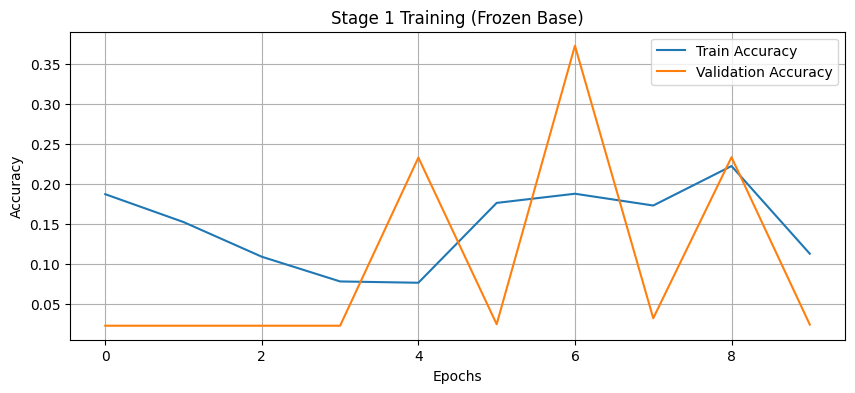

✅ Saved: /kaggle/working/stage2_finetuning_accuracy.png


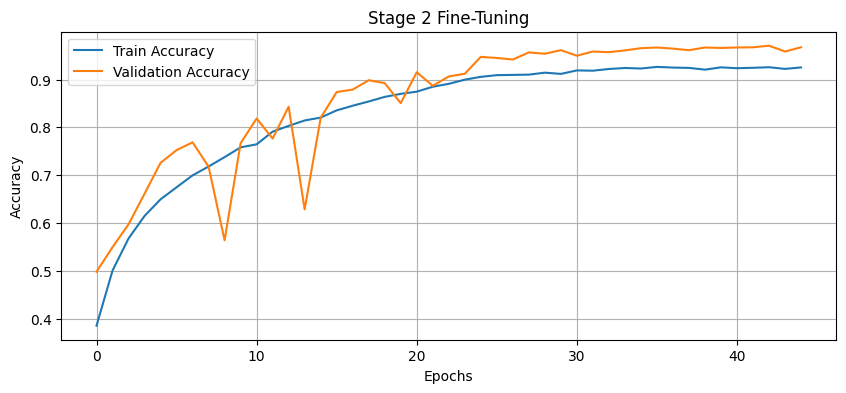

In [3]:
import matplotlib.pyplot as plt
import os

# Create output directory if it doesn't exist
output_dir = "/kaggle/working"
os.makedirs(output_dir, exist_ok=True)

def plot_history(history, title, filename):
    plt.figure(figsize=(10,4))
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(title)
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    
    # Save the figure
    save_path = os.path.join(output_dir, filename)
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"✅ Saved: {save_path}")
    
    # Optionally show it
    plt.show()

# Plot and save both stage histories
plot_history(history1, "Stage 1 Training (Frozen Base)", "stage1_training_accuracy.png")
plot_history(history2, "Stage 2 Fine-Tuning", "stage2_finetuning_accuracy.png")


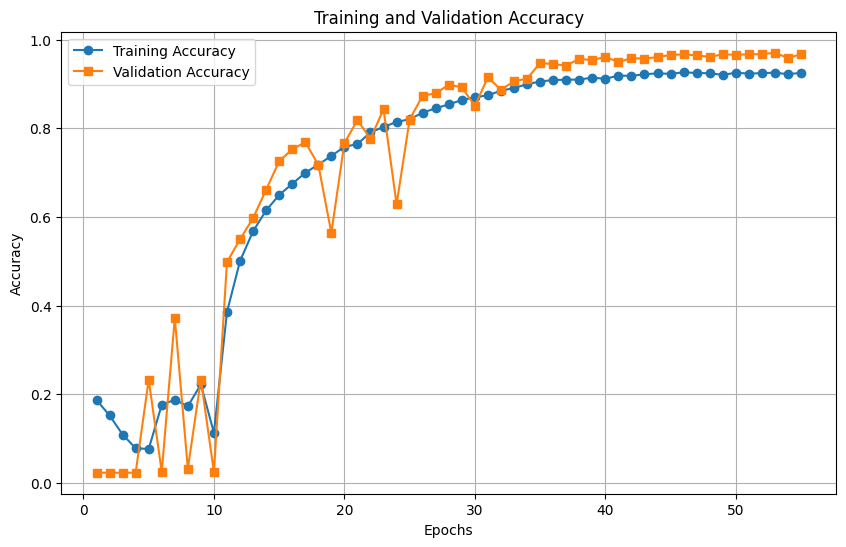

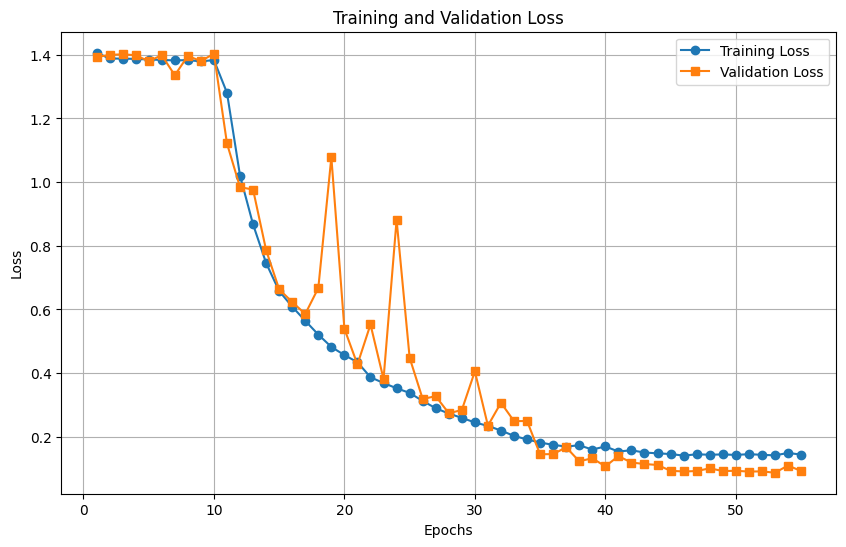

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# ---------------------------
# Combine Stage 1 and Stage 2 histories
# ---------------------------
# Accuracy
acc = history1.history['accuracy'] + history2.history['accuracy']
val_acc = history1.history['val_accuracy'] + history2.history['val_accuracy']

# Loss
loss = history1.history['loss'] + history2.history['loss']
val_loss = history1.history['val_loss'] + history2.history['val_loss']

epochs = range(1, len(acc)+1)

# ---------------------------
# 1️⃣ Training and Validation Accuracy
# ---------------------------
plt.figure(figsize=(10,6))
plt.plot(epochs, acc, label='Training Accuracy', marker='o')
plt.plot(epochs, val_acc, label='Validation Accuracy', marker='s')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# ---------------------------
# 2️⃣ Training and Validation Loss
# ---------------------------
plt.figure(figsize=(10,6))
plt.plot(epochs, loss, label='Training Loss', marker='o')
plt.plot(epochs, val_loss, label='Validation Loss', marker='s')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()




135/135 ━━━━━━━━━━━━━━━━━━━━ 27s 111ms/step


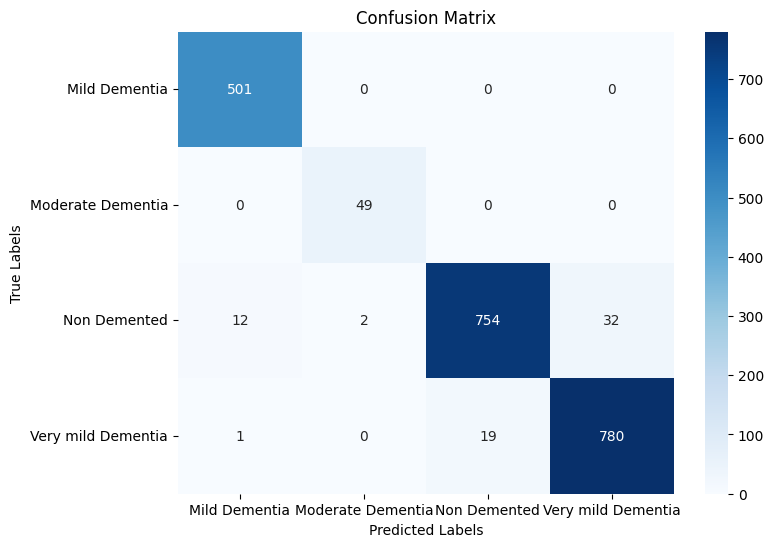

📊 Classification Report:


,precision,recall,f1-score,support
Mild Dementia,0.975,1.000,0.987,501.000
Moderate Dementia,0.961,1.000,0.980,49.000
Non Demented,0.975,0.942,0.959,800.000
Very mild Dementia,0.961,0.975,0.968,800.000
accuracy,0.969,0.969,0.969,0.969
macro avg,0.968,0.979,0.973,2150.000
weighted avg,0.969,0.969,0.969,2150.000


In [4]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# Predict on test set
y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_generator.classes
class_names = list(test_generator.class_indices.keys())

# -------------------------------
# CONFUSION MATRIX
# -------------------------------
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

# -------------------------------
# CLASSIFICATION REPORT (TABLE)
# -------------------------------
report_dict = classification_report(y_true, y_pred_classes, target_names=class_names, output_dict=True)
report_df = pd.DataFrame(report_dict).transpose()

# Round values to 3 decimals for readability
report_df = report_df.round(3)

# Display neatly
print("📊 Classification Report:")
display(report_df)
